In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

def plot_decision_boundary(model, X, y, title="Granica decyzyjna"):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        preds = torch.sigmoid(model(grid))
        preds = (preds > 0.5).float().numpy()

    preds = preds.reshape(xx.shape)
    plt.contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.bwr)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.bwr)
    plt.title(title)

X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# WSTĘP

## 1998. Wczesne zatrzymanie (early stopping)

**Motywacja:** Kontrola przeuczenia bez potrzeby wyrafinowanej walidacji. Stosuje się patrząc kiedy w trakcie uczenia model najlepiej działa na zbiorze walidacyjnym (jak zaczyna loss na zbiorze walidacyjnym rosnąć, to oznacza, że model zaczyna się overfitować, i można zatrzymać uczenie).

**Dlaczego ważne:**

* Prosta forma regularyzacji
* Przydatne przy ograniczonych danych

**🔗 Praca:** Prechelt, 1998: ["Early Stopping — But When?"](https://link.springer.com/chapter/10.1007/3-540-49430-8_3)
*Jedna z pierwszych analiz teoretycznych i empirycznych skuteczności tej metody.*

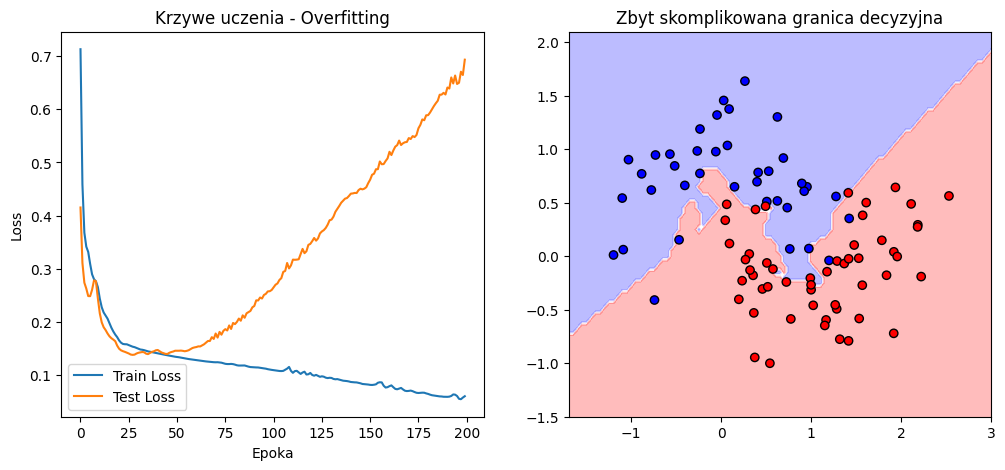

In [2]:
class OverfittingMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 200),
            nn.ReLU(),
            nn.Linear(200, 200),
            nn.ReLU(),
            nn.Linear(200, 1),
        )

    def forward(self, x):
        return self.net(x)

model_overfit = OverfittingMLP()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_overfit.parameters(), lr=0.01)

epochs = 200
train_losses, test_losses = [], []

for epoch in range(epochs):
    model_overfit.train()
    optimizer.zero_grad()
    out = model_overfit(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model_overfit.eval()
    with torch.no_grad():
        test_out = model_overfit(X_test_t)
        test_loss = criterion(test_out, y_test_t)
        test_losses.append(test_loss.item())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Krzywe uczenia - Overfitting")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(model_overfit, X_test, y_test, "Zbyt skomplikowana granica decyzyjna")
plt.show()

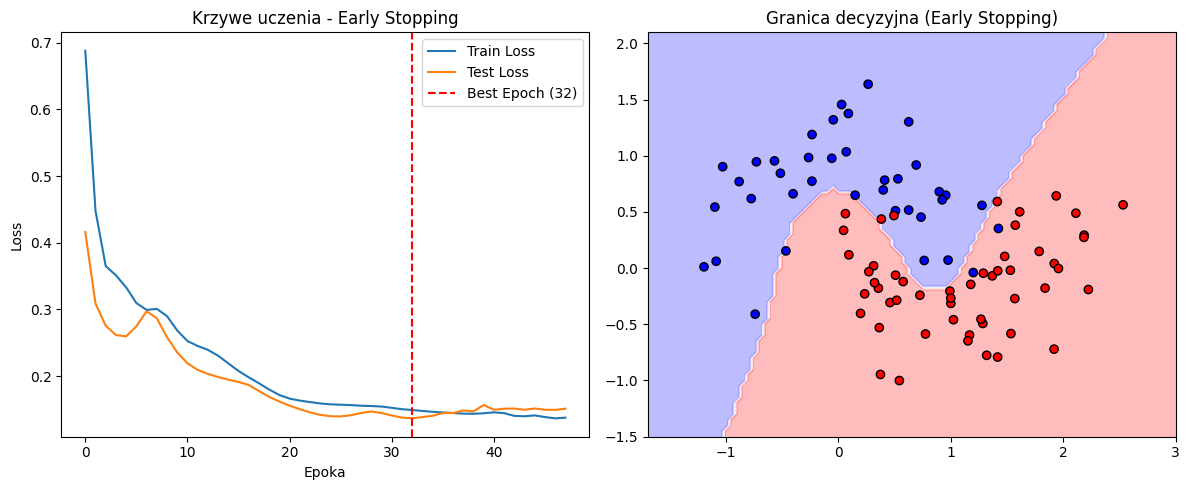

In [3]:
model_es = OverfittingMLP()
criterion = nn.BCEWithLogitsLoss()
optimizer_es = optim.Adam(model_es.parameters(), lr=0.01)

patience = 15
best_loss = float('inf')
epochs_no_improve = 0
best_model_wts = None
best_epoch = 0

train_losses_es, test_losses_es = [], []

for epoch in range(epochs):
    model_es.train()
    optimizer_es.zero_grad()
    out = model_es(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer_es.step()

    train_losses_es.append(loss.item())

    model_es.eval()
    with torch.no_grad():
        test_out = model_es(X_test_t)
        test_loss = criterion(test_out, y_test_t)
        test_losses_es.append(test_loss.item())

    if test_loss < best_loss:
        best_loss = test_loss
        epochs_no_improve = 0
        best_epoch = epoch
        best_model_wts = copy.deepcopy(model_es.state_dict())
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        model_es.load_state_dict(best_model_wts)
        break

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_es, label='Train Loss')
plt.plot(test_losses_es, label='Test Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title("Krzywe uczenia - Early Stopping")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(model_es, X_test, y_test, "Granica decyzyjna (Early Stopping)")

plt.tight_layout()
plt.show()

## 2010/2015. Właściwa inicjalizacja wag: Xavier i He

**Motywacja:** Losowe inicjalizowanie wag zbyt małymi lub zbyt dużymi wartościami powoduje zanikanie lub eksplozję sygnałów i gradientów. Równocześnie na początku uczenia sieci często inicjalizowano samymi zerami, co powodowało zanikanie sygnałów i gradientów, oraz dodakowo wszystkie neurony w warstwie uczyły się identycznie i sieć nie mogła się efektywnie uczyć.

###  Xavier (Glorot, 2010)

* Zakładamy, że chcemy, aby wariancja aktywacji oraz gradientów była taka sama na wejściu i wyjściu z każdej warstwy.
* Jeśli $x$ ma wariancję $\mathrm{Var}[x] = v$, to dla wag $W$ losowanych z rozkładu $\mathcal{N}(0, \sigma^2)$ i wyjścia $Wx$,
  $\mathrm{Var}[Wx] = n \cdot \sigma^2 \cdot v$
* Dla stabilności uczymy się tak, aby:
  $\sigma^2 = \frac{2}{n_{\text{in}} + n_{\text{out}}}$

**🔗 Praca:** Glorot & Bengio, 2010: ["Understanding the difficulty of training deep feedforward neural networks"](http://proceedings.mlr.press/v9/glorot10a.html)
*Zaproponowano metodę inicjalizacji wag redukującą problem zanikania/eksplozji gradientów.*

###  He (dla ReLU)

* ReLU ucinają wartości ujemne, dlatego zachowuje się jak funkcja o wartości 0 dla ok. połowy przypadków.

* W związku z tym potrzebujemy większej wariancji:
  $\sigma^2 = \frac{2}{n_{\text{in}}}$

**Dlaczego ważne:** Bez dobrej inicjalizacji uczenie gębokich sieci jest niestabilne. Te techniki ustabilizowały i przyspieszyły trening.

**🔗 Praca:** He et al., 2015: ["Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification"](https://arxiv.org/abs/1502.01852)
*Dostosowanie inicjalizacji wag do ReLU — umożliwiło trenowanie bardzo głębokich sieci CNN.*

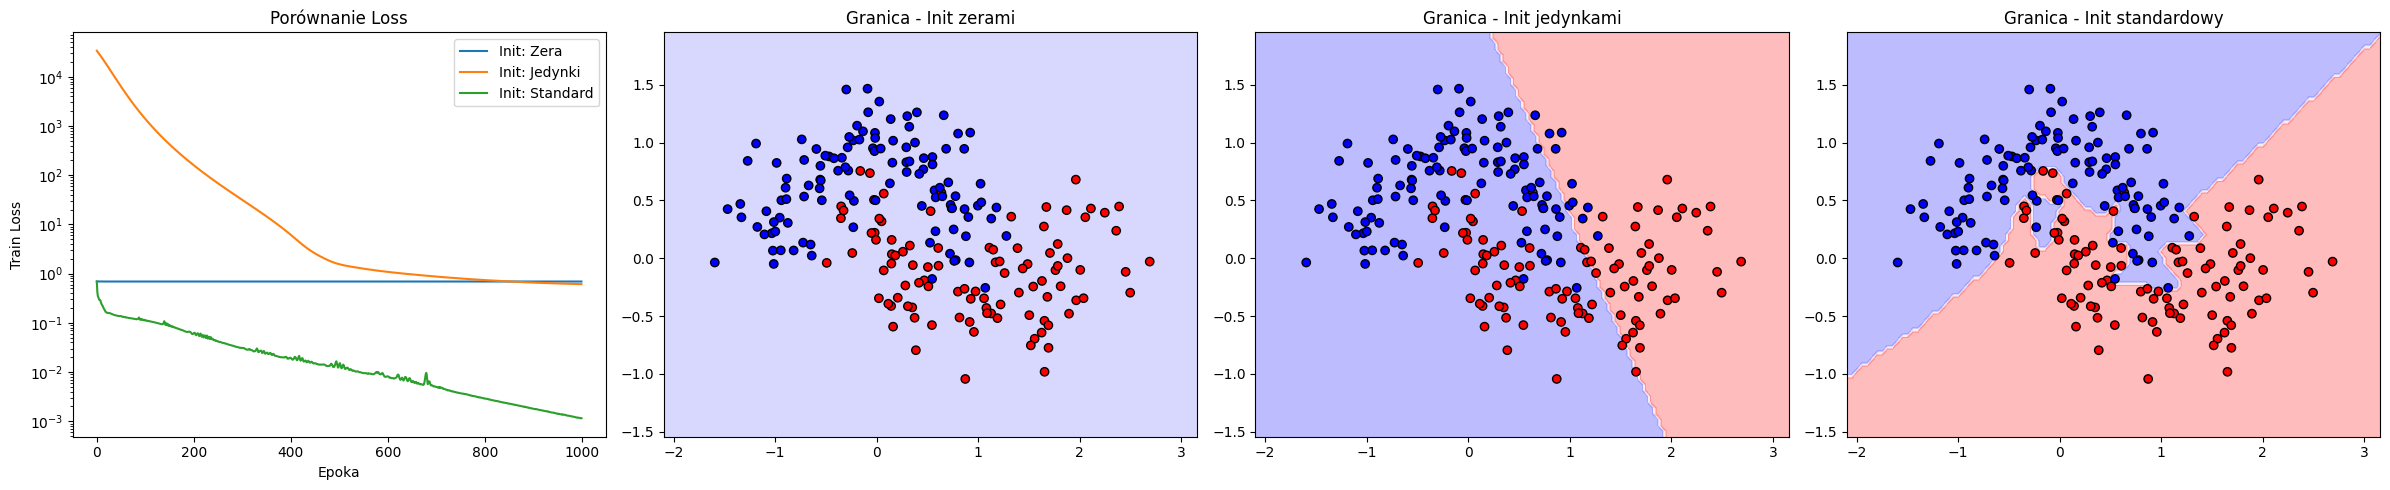

In [4]:
def init_zeros(m):
    if isinstance(m, nn.Linear):
        nn.init.zeros_(m.weight)
        nn.init.zeros_(m.bias)

def init_ones(m):
    if isinstance(m, nn.Linear):
        nn.init.ones_(m.weight)
        nn.init.ones_(m.bias)

model_zeros = OverfittingMLP()
model_zeros.apply(init_zeros)

model_ones = OverfittingMLP()
model_ones.apply(init_ones)

model_standard = OverfittingMLP()

opt_zeros = optim.Adam(model_zeros.parameters(), lr=0.01)
opt_ones = optim.Adam(model_ones.parameters(), lr=0.01)
opt_standard = optim.Adam(model_standard.parameters(), lr=0.01)

loss_zeros, loss_ones, loss_standard = [], [], []

for epoch in range(1000):
    opt_zeros.zero_grad()
    l_z = criterion(model_zeros(X_train_t), y_train_t)
    l_z.backward()
    opt_zeros.step()
    loss_zeros.append(l_z.item())

    opt_ones.zero_grad()
    l_o = criterion(model_ones(X_train_t), y_train_t)
    l_o.backward()
    opt_ones.step()
    loss_ones.append(l_o.item())
    opt_standard.zero_grad()
    l_s = criterion(model_standard(X_train_t), y_train_t)
    l_s.backward()
    opt_standard.step()
    loss_standard.append(l_s.item())

plt.figure(figsize=(24, 5))

plt.subplot(1, 4, 1)
plt.plot(loss_zeros, label='Init: Zera')
plt.plot(loss_ones, label='Init: Jedynki')
plt.plot(loss_standard, label='Init: Standard')
plt.yscale('log')
plt.title("Porównanie Loss")
plt.xlabel("Epoka")
plt.ylabel("Train Loss")
plt.legend()

plt.subplot(1, 4, 2)
plot_decision_boundary(model_zeros, X_train, y_train, "Granica - Init zerami")
plt.subplot(1, 4, 3)
plot_decision_boundary(model_ones, X_train, y_train, "Granica - Init jedynkami")
plt.subplot(1, 4, 4)
plot_decision_boundary(model_standard, X_train, y_train, "Granica - Init standardowy")

plt.tight_layout()
plt.show()

## 2014 Dropout

**Motywacja:**
Sieci MLP (i głębsze modele) mają tendencję do przeuczenia się, szczególnie przy małych zbiorach danych lub gdy liczba parametrów jest duża.
**Dropout** to prosta, stochastyczna metoda regularizacji, która można interpretować jako *uśrednianie wielu modeli (ensemble learning)*.

###  Jak działa:

W czasie treningu, każda aktywacja $x_i$ jest z pewnym prawdopodobieństwem $1 - p$ **wyłączana** (ustawiana na zero):
$$
m_i \sim \text{Bernoulli}(p), \quad
\tilde{x}_i = \frac{m_i x_i}{p}
$$
gdzie:

* $p$ — prawdopodobieństwo *zachowania* neuronu (keep probability),
* $m_i$ — losowa maska (0 lub 1),
* $\tilde{x}_i$ — przeskalowana aktywacja po dropoutcie.

###  Dlaczego trzeba **reskalować**?

Bez czynnika $\frac{1}{p}$, średnia wartość aktywacji w czasie treningu byłaby mniejsza niż podczas ewaluacji — sieć „widziałaby” mniejsze sygnały i musiałaby się do tego dostosować.

Dodanie przeskalowania przez $\frac{1}{p}$ gwarantuje, że:
$$
\mathbb{E}[\tilde{x}_i] = x_i
$$
czyli **średni sygnał pozostaje taki sam** niezależnie od maski.

###  Tryb ewaluacji (`model.eval()`)

Podczas testowania (ewaluacji):

* **Dropout jest wyłączony** — maska $m_i = 1$ dla wszystkich neuronów.
* Nie wykonuje się już mnożenia przez maskę, ani skalowania.

Dzięki wcześniejszemu przeskalowaniu w fazie treningu,
model może w czasie ewaluacji działać deterministycznie, bez potrzeby korekty aktywacji —
**średnia wartość sygnału jest już zgodna z oczekiwaną.**

###  Alternatywna interpretacja: losowe podsieci

Dropout można interpretować jako trenowanie ogromnej liczby (nawet milionów) losowych **podsieci** — w każdej iteracji inne neurony są aktywne.
Parametry są współdzielone, więc ostateczny model to **uśrednienie** wszystkich tych podsieci.
Dlatego dropout działa jak **ensemble z ogromną liczbą modeli**, ale bez wzrostu kosztu obliczeń w fazie testowej.

###  Dropout jako **szacowanie niepewności (Monte Carlo Dropout)**

Choć standardowo dropout jest wyłączany w trybie ewaluacji,
można go **celowo pozostawić włączonego w fazie testowej**, aby uzyskać *różne predykcje* dla tego samego wejścia.

To podejście, znane jako **Monte Carlo Dropout (Gal & Ghahramani, 2016)**, pozwala oszacować **niepewność modelu**:
$$
\hat{y}^{(t)} = f_{\theta, m^{(t)}}(x), \quad t = 1, \ldots, T
$$

Średnia predykcji:
$$
\bar{y} = \frac{1}{T} \sum_t \hat{y}^{(t)}
$$
Wariancja predykcji:
$$
\text{Var}(y) = \frac{1}{T} \sum_t (\hat{y}^{(t)} - \bar{y})^2
$$
To pozwala traktować dropout jako **ensemble losowych modeli** także w czasie ewaluacji —
prosty sposób na przybliżone szacowanie niepewności (ang. *Bayesian approximation*).

###  Intuicja:

* Dropout zmusza sieć do tego, by nie polegała zbytnio na pojedynczych neuronach.
* Tworzy bardziej rozproszone, stabilne reprezentacje.
* Zwiększa odporność na zakłócenia wejścia i zmniejsza ryzyko przeuczenia.

###  Dlaczego ważne:

*  Zapobiega przeuczeniu
*  Wymusza redundancję i odporność reprezentacji
*  Uśrednia zachowanie wielu modeli
*  Może służyć do szacowania niepewności (MC Dropout)

**🔗 Prace:**

* Srivastava et al., 2014 — *Dropout: A Simple Way to Prevent Neural Networks from Overfitting*
* Gal & Ghahramani, 2016 — *Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning*


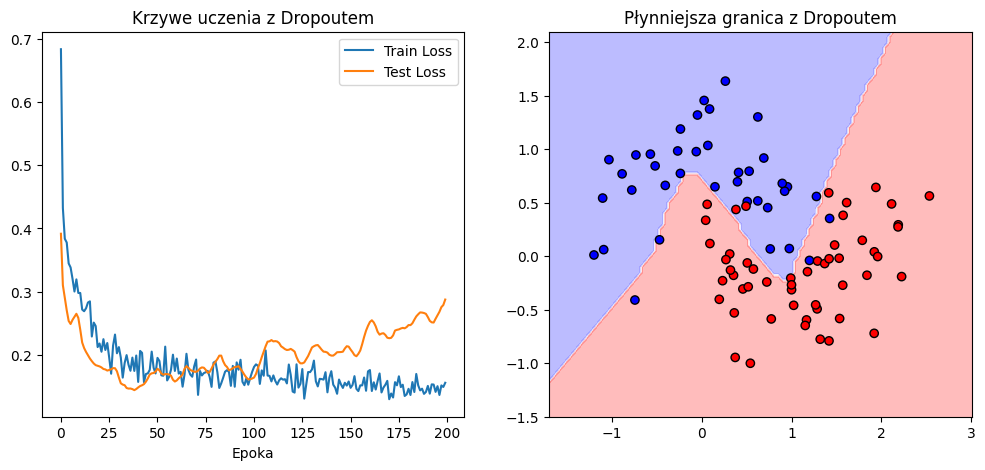

In [5]:
class DropoutMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 200),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(200, 200),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(200, 1),
        )

    def forward(self, x):
        return self.net(x)

model_dropout = DropoutMLP()
optimizer_dp = optim.Adam(model_dropout.parameters(), lr=0.01)

dp_train_losses, dp_test_losses = [], []
epochs = 200
for epoch in range(epochs):
    model_dropout.train()
    optimizer_dp.zero_grad()
    out = model_dropout(X_train_t)
    loss = criterion(out, y_train_t)
    loss.backward()
    optimizer_dp.step()
    dp_train_losses.append(loss.item())

    model_dropout.eval()
    with torch.no_grad():
        test_loss = criterion(model_dropout(X_test_t), y_test_t)
        dp_test_losses.append(test_loss.item())

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(dp_train_losses, label='Train Loss')
plt.plot(dp_test_losses, label='Test Loss')
plt.title("Krzywe uczenia z Dropoutem")
plt.xlabel("Epoka")
plt.legend()

plt.subplot(1, 2, 2)
plot_decision_boundary(model_dropout, X_test, y_test, "Płynniejsza granica z Dropoutem")
plt.show()

## 2015 Połączenia rezydualne

**Motywacja:** W bardzo głębokich sieciach gradienty mogą zanikać lub eksplodować. Połączenia rezydualne tworzą ścieżkę skrótu, która pozwala bezpośrednio przenosić informacje i gradienty. Dodatkowo kolejne warstwy mogą się uczyć tylko poprawiać to co poprzednie zrobiły (bez połączeń rezydualnych każda warstwa musi istotnie zmodyfikować to co zrobiła poprzednia, i w konsekwencji nie da się robić drobnych poprawek).

Oprócz batch-norm, najważniejsza technika pozwalająca uczyć bardzo głębokie sieci (1000 warstw i więcej)

###  Schemat:

Budujemy sieć która pozwala przekazywać identyczność
$$
x \leftarrow x + A \cdot \text{ReLU}(B \cdot x)
$$

* Pozwala warstwom uczyć się „poprawek” względem poprzedniego sygnału, zamiast zupełnie nowego przekształcenia.

###  Intuicja:

* Ułatwia propagację gradientów do wcześniejszych warstw
* Sieć może łatwiej uczyć się tożsamości (czyli nie zmieniać sygnału), jeśli to optymalne

**Dlaczego ważne:**

* Umożliwiają trenowanie bardzo głębokich sieci (setki warstw)
* Zapobiegają degradacji jakości w bardzo głębokich modelach


**🔗 Praca:** He et al., 2015: ["Deep Residual Learning for Image Recognition"](https://arxiv.org/abs/1512.03385)
*ResNet wygrał ILSVRC 2015 — początek ery bardzo głębokich sieci.*

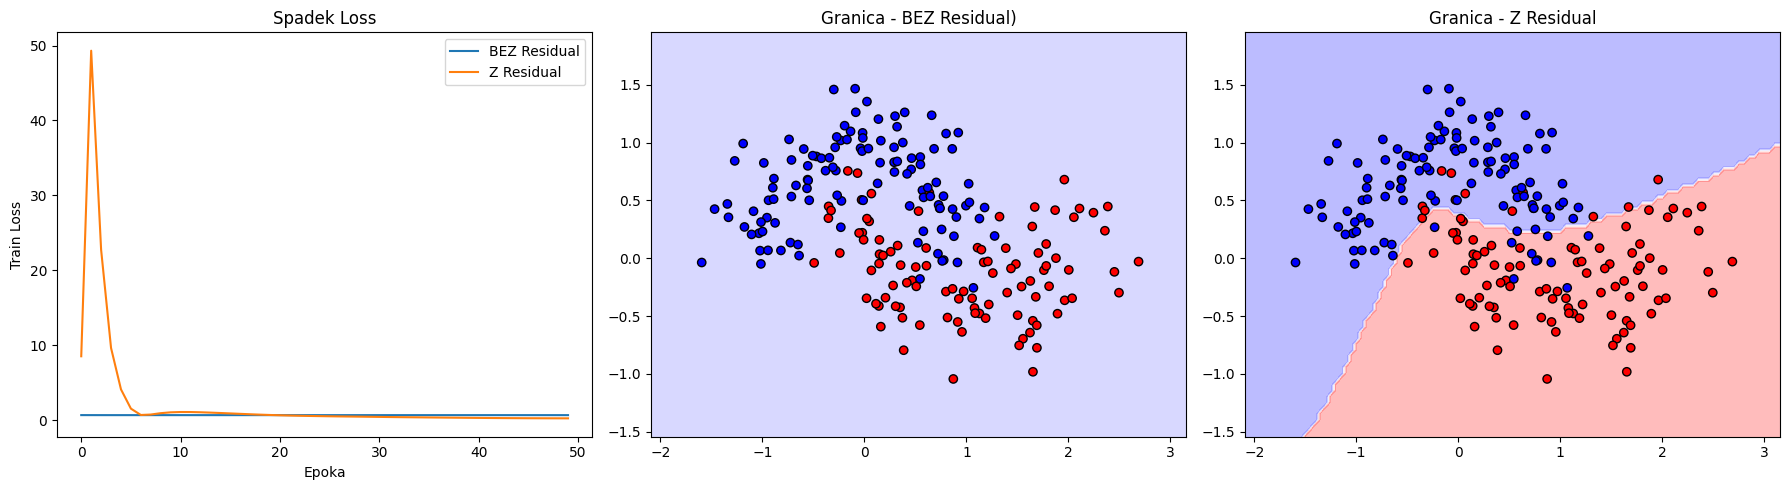

In [6]:
class DeepPlainMLP(nn.Module):
    def __init__(self, num_layers=25):
        super().__init__()
        layers = [nn.Linear(2, 32), nn.ReLU()]
        for _ in range(num_layers):
            layers.extend([nn.Linear(32, 32), nn.ReLU()])
        layers.append(nn.Linear(32, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class ResBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Sequential(nn.Linear(32, 32), nn.ReLU())
    def forward(self, x):
        return x + self.layer(x)

class DeepResMLP(nn.Module):
    def __init__(self, num_layers=25):
        super().__init__()
        self.in_layer = nn.Sequential(nn.Linear(2, 32), nn.ReLU())
        self.res_blocks = nn.Sequential(*[ResBlock() for _ in range(num_layers)])
        self.out_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.in_layer(x)
        x = self.res_blocks(x)
        return self.out_layer(x)

plain_model = DeepPlainMLP()
res_model = DeepResMLP()

opt_plain = optim.Adam(plain_model.parameters(), lr=0.005)
opt_res = optim.Adam(res_model.parameters(), lr=0.005)

loss_plain, loss_res = [], []
for epoch in range(50):
    opt_plain.zero_grad()
    l_p = criterion(plain_model(X_train_t), y_train_t)
    l_p.backward()
    opt_plain.step()
    loss_plain.append(l_p.item())

    opt_res.zero_grad()
    l_r = criterion(res_model(X_train_t), y_train_t)
    l_r.backward()
    opt_res.step()
    loss_res.append(l_r.item())

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(loss_plain, label='BEZ Residual')
plt.plot(loss_res, label='Z Residual')
plt.title("Spadek Loss")
plt.xlabel("Epoka")
plt.ylabel("Train Loss")
plt.legend()
plt.subplot(1, 3, 2)
plot_decision_boundary(plain_model, X_train, y_train, "Granica - BEZ Residual)")
plt.subplot(1, 3, 3)
plot_decision_boundary(res_model, X_train, y_train, "Granica - Z Residual")

plt.tight_layout()
plt.show()

# Zadania:

### Zadanie 1: BatchNorm i LayerNorm

Batch Normalization działa bardzo dobrze dla dużych batchy, ale słabo w sytuacjach, gdy batch jest mały (np. w modelach sekwencyjnych, RNN, czy transformerach).
Layer Normalization rozwiązuje ten problem — zamiast normalizować po batchu, normalizuje po wymiarach wewnątrz pojedynczej próbki.
Dzięki temu działa identycznie niezależnie od rozmiaru batcha i jest stabilna w modelach przetwarzających dane sekwencyjnie.

Zaprojektuj eksperyment, który empirycznie udowodni słabość BatchNorm przy małym batchu oraz skuteczność LayerNorm w tych samych warunkach.


1. Przygotuj syntetyczny zbiór danych 2D (np. `make_moons` z biblioteki `sklearn`).
2. Skonfiguruj ładowanie danych w taki sposób, aby ekstremalnie ograniczyć rozmiar paczki danych (np. ustaw `batch_size=2` lub `4`).
3. Napisz klasę prostej sieci MLP. Następnie stwórz jej trzy instancje, różniące się tylko zastosowaną normalizacją pomiędzy warstwami liniowymi:
   * Wariant A: Brak normalizacji.
   * Wariant B: Zastosowanie `nn.BatchNorm1d`.
   * Wariant C: Zastosowanie `nn.LayerNorm`.
4. Przetrenuj wszystkie trzy modele przez tę samą liczbę epok, używając tego samego optymalizatora i funkcji straty. Pamiętaj o odpowiednich trybach `.train()` i `.eval()`.

Przygotuj jeden wspólny wykres liniowy pokazujący spadek błędu (Train Loss) dla wszystkich trzech wariantów. Powinieneś wyraźnie zaobserwować oscylacje/szum dla modelu z BatchNorm.

Narysuj na wykresach 2D (scatter plot danych + contour plot przewidywań), w jaki sposób każdy z modeli podzielił przestrzeń.



Trenowanie: Brak Norm...
Trenowanie: BatchNorm1d...
Trenowanie: LayerNorm...


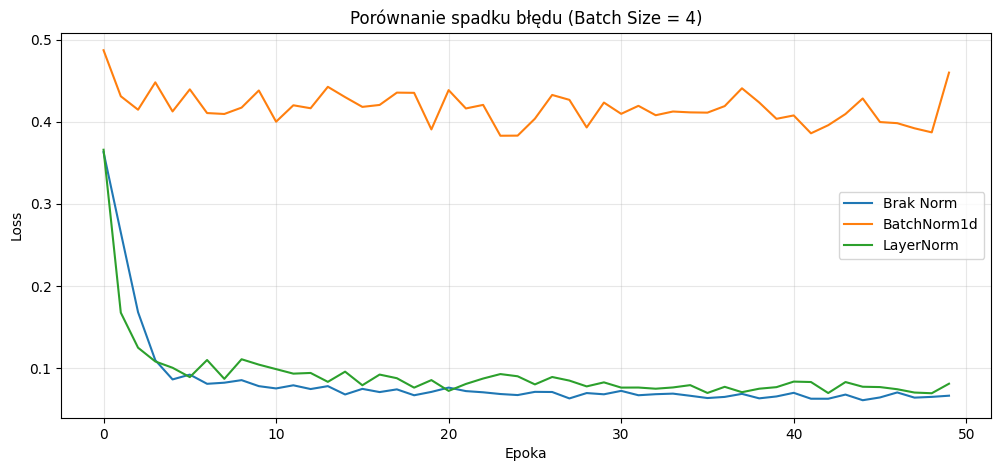

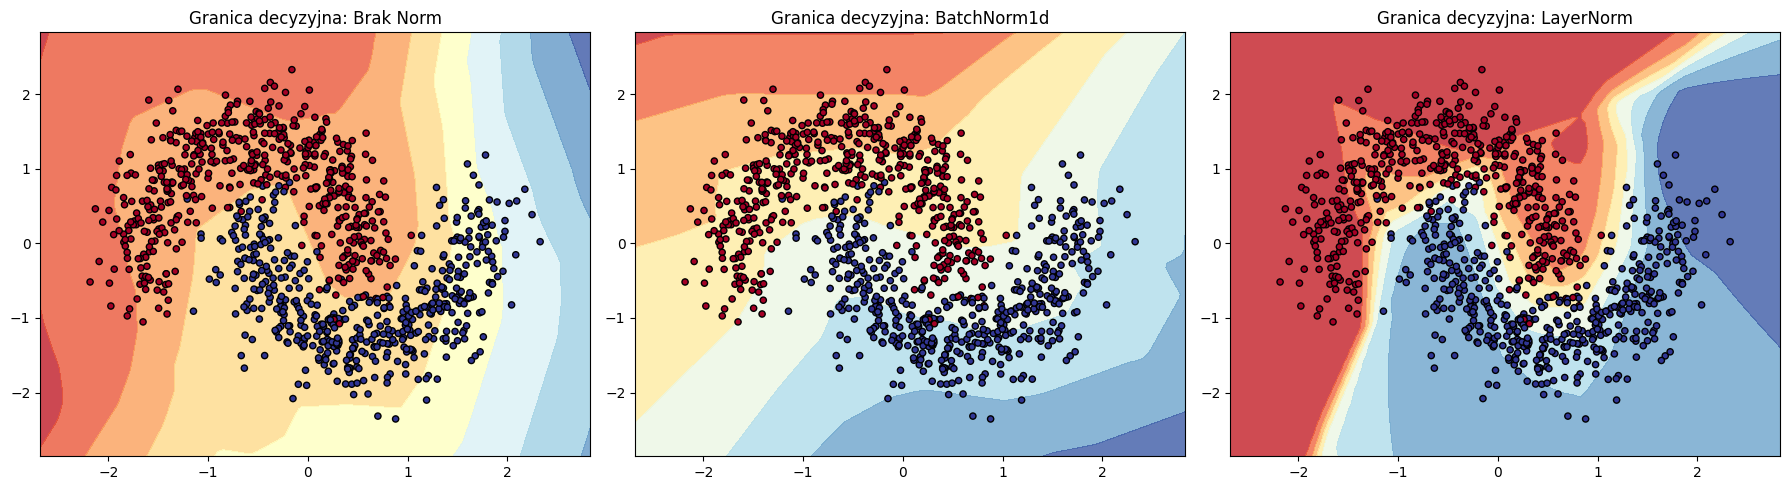

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)

X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).unsqueeze(1)

dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

class SimpleMLP(nn.Module):
    def __init__(self, norm_type=None):
        super(SimpleMLP, self).__init__()
        self.layers = nn.ModuleList()

        self.layers.append(nn.Linear(2, 16))
        if norm_type == 'batch':
            self.layers.append(nn.BatchNorm1d(16))
        elif norm_type == 'layer':
            self.layers.append(nn.LayerNorm(16))
        self.layers.append(nn.ReLU())

        self.layers.append(nn.Linear(16, 8))
        if norm_type == 'batch':
            self.layers.append(nn.BatchNorm1d(8))
        elif norm_type == 'layer':
            self.layers.append(nn.LayerNorm(8))
        self.layers.append(nn.ReLU())

        self.layers.append(nn.Linear(8, 4))
        if norm_type == 'batch':
            self.layers.append(nn.BatchNorm1d(4))
        elif norm_type == 'layer':
            self.layers.append(nn.LayerNorm(4))
        self.layers.append(nn.ReLU())

        self.layers.append(nn.Linear(4, 1))
        #self.layers.append(nn.Sigmoid())

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

def train_model(model, loader, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    #criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    losses = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_X, batch_y in loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(loader))
    return losses

models = {
    'Brak Norm': SimpleMLP(norm_type=None),
    'BatchNorm1d': SimpleMLP(norm_type='batch'),
    'LayerNorm': SimpleMLP(norm_type='layer')
}

history = {}
for name, model in models.items():
    print(f"Trenowanie: {name}...")
    history[name] = train_model(model, train_loader)

plt.figure(figsize=(12, 5))
for name, losses in history.items():
    plt.plot(losses, label=name)
plt.title("Porównanie spadku błędu (Batch Size = 4)")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

for ax, (name, model) in zip(axes, models.items()):
    model.eval()
    with torch.no_grad():
        Z = model(grid_tensor).reshape(xx.shape).numpy()

    ax.contourf(xx, yy, Z, alpha=0.8, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdYlBu', s=20)
    ax.set_title(f"Granica decyzyjna: {name}")

plt.tight_layout()
plt.show()

### Zadanie 2: Gradient Clipping

W głębokich modelach podczas propagacji wstecznej często pojawia się problem „wybuchających” gradientów. Gradienty potrafią urosnąć do ogromnych rozmiarów, co wyrzuca model poza obszar „rozsądnego” minimum.

Stwórz warunki, w których uczenie ulegnie destabilizacji ("wybuchnie"), a następnie użyj techniki Gradient Clipping, aby ustabilizować trening i poprawić model.

1. Zbuduj celowo przesadzoną, głęboką sieć MLP i dobierz do niej duży współczynnik uczenia (np. `lr=0.1` lub `0.5`). Wykorzystaj syntetyczny zbiór danych.
2. Napisz standardową pętlę uczącą. Monitoruj i zapisuj wartości funkcji straty. Zaobserwuj, w której epoce wartość nagle gwałtownie rośnie lub staje się NaN.
3. Skopiuj kod pętli uczącej i zmodyfikuj go. Tuż po obliczeniu gradientów (`loss.backward()`), ale jeszcze przed aktualizacją wag (`optimizer.step()`), zaimplementuj normowanie gradientu za pomocą funkcji Pytorch .
4. Ponownie uruchom uczenie i sprawdź, czy model tym razem zdołał się nauczyć bez wybuchu gradientu.

Przygotuj wykres krzywych uczenia porównujący oba przebiegi na jednym obrazku lub obok siebie. Pokaż moment urwania się wykresu (lub drastycznego skoku) dla modelu zepsutego oraz płynny spadek błędu dla modelu naprawionego za pomocą Clippingu.

Start treningu: Clipping=False
  -> Model wybuchł w epoce 14 (NaN)!
Start treningu: Clipping=True


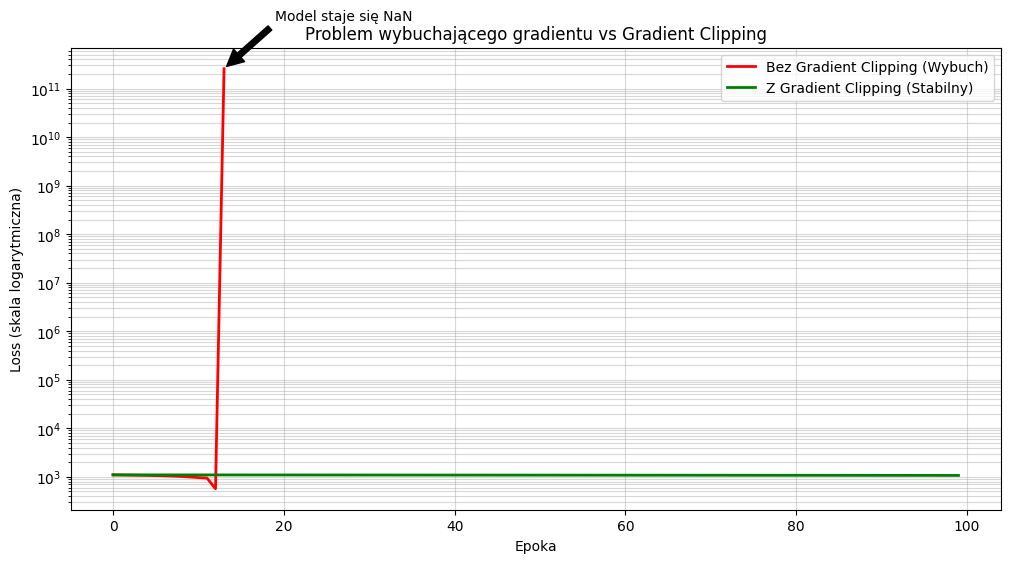

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

X = torch.linspace(-5, 5, 500).reshape(-1, 1)
y = 0.5 * X**3 - 2 * X**2 + X + 5 + torch.randn(X.size()) * 5

def create_model():
    layers = []
    input_dim = 1
    for _ in range(10): # 10  warstw
        layers.append(nn.Linear(input_dim, 100))
        layers.append(nn.ReLU())
        input_dim = 100
    layers.append(nn.Linear(100, 1))
    return nn.Sequential(*layers)

def train_experiment(use_clipping=False):
    model = create_model()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    losses = []
    print(f"Start treningu: Clipping={use_clipping}")

    for epoch in range(100):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)

        # Jeśli loss stanie się NaN, przerywamy (model wybuchł)
        if torch.isnan(loss):
            print(f"  -> Model wybuchł w epoce {epoch} (NaN)!")
            break

        loss.backward()

        if use_clipping:
            # Gradient Clipping: ogranicza normę gradientu do 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        losses.append(loss.item())

    return losses

loss_no_clip = train_experiment(use_clipping=False)
loss_with_clip = train_experiment(use_clipping=True)

plt.figure(figsize=(12, 6))

# bez clippingu
plt.plot(loss_no_clip, label='Bez Gradient Clipping (Wybuch)', color='red', linewidth=2)
# clippingiem
plt.plot(loss_with_clip, label='Z Gradient Clipping (Stabilny)', color='green', linewidth=2)

plt.yscale('log') # Skala logarytmiczna lepiej pokazuje skok do ogromnych wartości
plt.title("Problem wybuchającego gradientu vs Gradient Clipping")
plt.xlabel("Epoka")
plt.ylabel("Loss (skala logarytmiczna)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.annotate('Model staje się NaN', xy=(len(loss_no_clip)-1, loss_no_clip[-1]),
             xytext=(len(loss_no_clip)+5, loss_no_clip[-1]*10),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()